# Linear regression

This notebook implements linear regression with four different approaches:
1. Scikit-learn
2. PyTorch
3. Closed-form solution (without using a framework)
4. Gradient descent (without using a framework)

In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import random_split, TensorDataset, DataLoader

### Create synthetic dataset

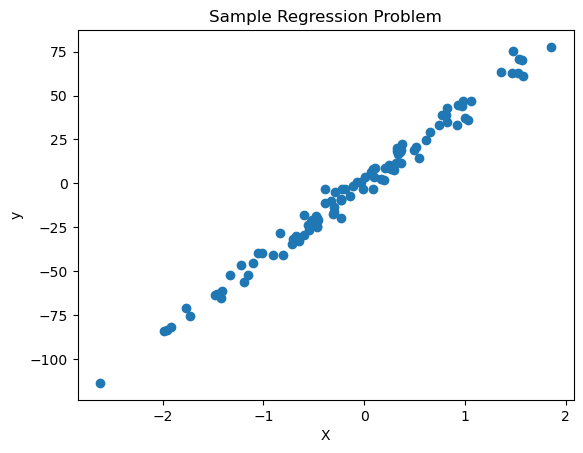

In [2]:
X, y = make_regression(n_samples=100, n_features=1, noise=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

figure, axis = plt.subplots()
axis.scatter(X, y)
axis.set_xlabel("X")
axis.set_ylabel("y")
axis.set_title("Sample Regression Problem")
plt.show()

### 1. Scikit-learn

In [3]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)
y_pred_train = sklearn_model.predict(X_test)
print(f"Parameters: {sklearn_model.intercept_}, {sklearn_model.coef_.item()}")
print(f"MSE: {mean_squared_error(y_test, y_pred_train)}")

Parameters: -0.19927277339938776, 43.048497807907495
MSE: 27.90955096579052


### 2. PyTorch

In [4]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    
    def forward(self, x):
        return self.linear(x)

dataset = TensorDataset(
    torch.from_numpy(X.astype("float32")),
    torch.from_numpy(y.astype("float32")).unsqueeze(1)
)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

pytorch_model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(pytorch_model.parameters(), lr=0.01)
for parameter in pytorch_model.parameters():
    print(parameter)

Parameter containing:
tensor([[0.4397]], requires_grad=True)
Parameter containing:
tensor([0.0333], requires_grad=True)


In [5]:
def train(train_losses):
    pytorch_model.train()
    train_loss = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        y_pred = pytorch_model(X)
        loss = criterion(y_pred, y)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    average_loss = train_loss / len(train_loader)
    print(f"Training loss: {average_loss}")
    train_losses.append(average_loss)

def test(test_losses):
    pytorch_model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in test_loader:
            y_pred = pytorch_model(X)
            loss = criterion(y_pred, y)
            test_loss += loss
    average_loss = test_loss / len(test_loader)
    test_losses.append(average_loss)
    print(f"Testing loss: {average_loss}")

In [6]:
epochs = 30
pytorch_train_losses = []
pytorch_test_losses = []
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}")
    train(pytorch_train_losses)
    test(pytorch_test_losses)
    print()

Epoch 1
Training loss: 1163.6799377441407
Testing loss: 1717.74169921875

Epoch 2
Training loss: 868.0641357421875
Testing loss: 1396.9801025390625

Epoch 3
Training loss: 652.6054534912109
Testing loss: 1087.5072021484375

Epoch 4
Training loss: 493.55469818115233
Testing loss: 836.4253540039062

Epoch 5
Training loss: 374.66983489990236
Testing loss: 626.5419311523438

Epoch 6
Training loss: 286.9890838623047
Testing loss: 478.6331787109375

Epoch 7
Training loss: 221.09920654296874
Testing loss: 325.3665771484375

Epoch 8
Training loss: 171.25212173461915
Testing loss: 265.01123046875

Epoch 9
Training loss: 134.59316177368163
Testing loss: 232.9359588623047

Epoch 10
Training loss: 106.50603866577148
Testing loss: 205.5584716796875

Epoch 11
Training loss: 85.36443481445312
Testing loss: 128.94741821289062

Epoch 12
Training loss: 69.36444931030273
Testing loss: 102.8677978515625

Epoch 13
Training loss: 57.437754440307614
Testing loss: 81.14936065673828

Epoch 14
Training loss: 48

### 3. Closed-form solution

In [7]:
def z(theta, X):
    return X @ theta

def mse(y_actual, y_predicted):
    return ((y_actual - y_predicted)**2).mean()

def augment(X):
    ones = np.ones((X.shape[0], 1))
    return np.concat((ones, X), axis=1)

# Add dummy column of ones to X to be multiplied by bias term
X_train_augmented = augment(X_train)
X_test_augmented = augment(X_test)

# Calculate optimal values for theta
closed_form_theta = np.linalg.inv(X_train_augmented.transpose() @ X_train_augmented) @ X_train_augmented.transpose() @ y_train

y_pred = z(closed_form_theta, X_test_augmented)

print(f"Parameters: {closed_form_theta}")
print(f"MSE: {mse(y_test, y_pred)}")

Parameters: [-0.19927277 43.04849781]
MSE: 27.90955096579051


### 4. Gradient descent

In [8]:


rng = np.random.default_rng()
gradient_descent_theta = rng.random(size=2)
learning_rate = 0.5
m = X_train_augmented.shape[0]
epochs = 30
gradient_descent_train_losses = []
gradient_descent_test_losses = []
for epoch in range(epochs):
    y_pred_train = z(gradient_descent_theta, X_train_augmented)
    train_loss = mse(y_train, y_pred_train)
    gradient_descent_train_losses.append(train_loss)

    # Calculate gradient and update weights
    gradient = 1 / m * X_train_augmented.transpose() @ (y_pred_train - y_train)
    gradient_descent_theta -= learning_rate * gradient

    y_pred_test = z(gradient_descent_theta, X_test_augmented)
    test_loss = mse(y_test, y_pred_test)
    gradient_descent_test_losses.append(test_loss)

    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"Parameters: {gradient_descent_theta}")
    print(f"Training MSE: {train_loss:.2f}")
    print(f"Testing MSE: {test_loss:.2f}")
    print()

Epoch 1/30
Parameters: [-3.00758247 17.99777397]
Training MSE: 1564.45
Testing MSE: 560.93

Epoch 2/30
Parameters: [-3.49274795 28.19614272]
Training MSE: 525.75
Testing MSE: 237.19

Epoch 3/30
Parameters: [-2.96617186 34.11984878]
Training MSE: 196.95
Testing MSE: 116.25

Epoch 4/30
Parameters: [-2.25611915 37.62159204]
Training MSE: 83.98
Testing MSE: 67.73

Epoch 5/30
Parameters: [-1.63699205 39.72169003]
Training MSE: 42.86
Testing MSE: 47.04

Epoch 6/30
Parameters: [-1.16903956 40.99575801]
Training MSE: 27.35
Testing MSE: 37.69

Epoch 7/30
Parameters: [-0.83897337 41.7756625 ]
Training MSE: 21.36
Testing MSE: 33.20

Epoch 8/30
Parameters: [-0.61512004 42.25636053]
Training MSE: 19.03
Testing MSE: 30.90

Epoch 9/30
Parameters: [-0.46693924 42.5541809 ]
Training MSE: 18.12
Testing MSE: 29.67

Epoch 10/30
Parameters: [-0.37038728 42.7394137 ]
Training MSE: 17.76
Testing MSE: 28.97

Epoch 11/30
Parameters: [-0.30814109 42.85495241]
Training MSE: 17.62
Testing MSE: 28.56

Epoch 12/30


### Visualize results

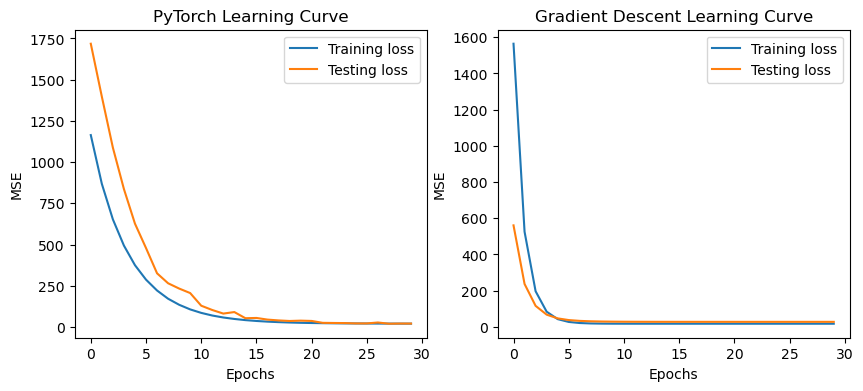

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.set_title("PyTorch Learning Curve")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("MSE")
ax1.plot(pytorch_train_losses, label="Training loss")
ax1.plot(pytorch_test_losses, label="Testing loss")
ax1.legend()

ax2.set_title("Gradient Descent Learning Curve")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("MSE")
ax2.plot(gradient_descent_train_losses, label="Training loss")
ax2.plot(gradient_descent_test_losses, label="Testing loss")
ax2.legend()

plt.show()

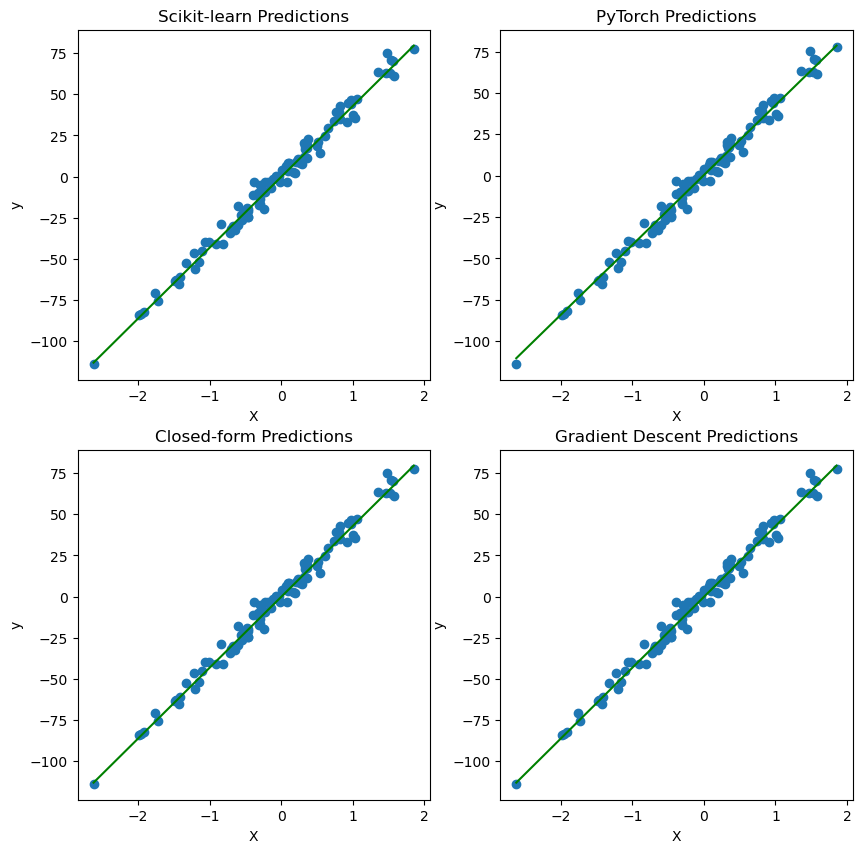

In [10]:
np_inputs = np.linspace(min(X), max(X))
torch_inputs = torch.from_numpy(np_inputs.astype("float32"))
np_inputs_augmented = augment(np_inputs)

pytorch_model.eval()
with torch.no_grad():
    sklearn_outputs = sklearn_model.predict(np_inputs)
    pytorch_outputs = pytorch_model(torch_inputs)
    closed_form_outputs = z(closed_form_theta, np_inputs_augmented)
    gradient_descent_outputs = z(gradient_descent_theta, np_inputs_augmented)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0, 0].set_title("Scikit-learn Predictions")
axs[0, 1].set_title("PyTorch Predictions")
axs[1, 0].set_title("Closed-form Predictions")
axs[1, 1].set_title("Gradient Descent Predictions")

axs[0, 0].plot(np_inputs, sklearn_outputs, "g")
axs[0, 1].plot(torch_inputs, pytorch_outputs, "g")
axs[1, 0].plot(np_inputs, closed_form_outputs, "g")
axs[1, 1].plot(np_inputs, gradient_descent_outputs, "g")

for i in range(2):
    for j in range(2):
        axs[i, j].set_xlabel("X")
        axs[i, j].set_ylabel("y")
        axs[i, j].scatter(X, y)

plt.show()